In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import gpplot as gpp
from statannotations.Annotator import Annotator
gpp.set_aesthetics(context = 'paper')

In [2]:
on_target_data = pd.read_csv('../../Data/cleanedData/CombinedCleanedDatasets.csv')
on_target_data

,Target Gene Symbol,chromosome,sgRNA Sequence,sgRNA Context Sequence,sgRNA 'Cut' Position,Strand of Target,Strand of sgRNA,TSS Position,sgRNA 'Cut' Site TSS Offset,Phenotype scores-ave_Rep1_Rep2,...,condition,Domain,DataSet,zscoreRelativeNC_signed,Avg_LFC_signed,z_scored_avg_lfc,rs3ChenSeqScore,cellDomainDataSet,z_score,signed_zscore
0,LARS2,chr3,AAAAAAAAAACAGGACACAG,CAGAAAAAAAAAAACAGGACACAGGGGAGA,45389244.0,+,-,45388577.0,667.0,NaN,...,A549,Kox1,InHouse,NaN,NaN,-0.398339,0.013999,A549_Kox1_InHouse,-0.398339,0.398339
1,LARS2,chr3,AAAAAAAAAACAGGACACAG,CAGAAAAAAAAAAACAGGACACAGGGGAGA,45389244.0,+,-,45388577.0,667.0,NaN,...,A549,Zim3,InHouse,NaN,NaN,-0.841793,0.013999,A549_Zim3_InHouse,-0.841793,0.841793
2,LARS2,chr3,AAAAAAAAAACAGGACACAG,CAGAAAAAAAAAAACAGGACACAGGGGAGA,45389244.0,+,-,45388577.0,667.0,NaN,...,HCT116,Zim3,InHouse,NaN,NaN,-0.992358,0.013999,HCT116_Zim3_InHouse,-0.992358,0.992358
3,COQ2,chr4,AAAAAAAAAAGGGCACCAAG,ATAAAAAAAAAAAAGGGCACCAAGTGGCCA,83285687.0,-,+,83284798.0,-888.0,NaN,...,A549,Kox1,InHouse,NaN,NaN,0.044728,-0.401549,A549_Kox1_InHouse,0.044728,-0.044728
4,COQ2,chr4,AAAAAAAAAAGGGCACCAAG,ATAAAAAAAAAAAAGGGCACCAAGTGGCCA,83285687.0,-,+,83284798.0,-888.0,NaN,...,A549,Zim3,InHouse,NaN,NaN,-0.190308,-0.401549,A549_Zim3_InHouse,-0.190308,0.190308
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
257411,WDR11,chr10,gctaggacctctactacaatgaa,GGCTAGGACCTCTACTACAATGAATGGGAG,120855890.0,+,+,120851363.0,4527.0,NaN,...,K562,Kox1,Gilbert,0.387317,0.354061,NaN,0.382810,K562_Kox1_Gilbert,0.387317,0.387317
257412,WDR11,chr10,gctaggacctctactacaatgaat,GCTAGGACCTCTACTACAATGAATGGGAGA,120855891.0,+,+,120851363.0,4528.0,NaN,...,K562,Kox1,Gilbert,-0.782858,-0.048063,NaN,0.654478,K562_Kox1_Gilbert,-0.782858,-0.782858
257413,WDR11,chr10,gtctttcatcaagtctgatgta,CAGTCTTTCATCAAGTCTGATGTAAGGTAT,120855971.0,+,+,120851363.0,4608.0,NaN,...,K562,Kox1,Gilbert,1.429277,0.712125,NaN,0.076554,K562_Kox1_Gilbert,1.429277,1.429277
257414,WDR11,chr10,gtaggtccaagtttcagtc,TTTATGTAGGTCCAAGTTTCAGTCTGGTAT,120856094.0,+,+,120851363.0,4731.0,NaN,...,K562,Kox1,Gilbert,0.553328,0.411110,NaN,0.717680,K562_Kox1_Gilbert,0.553328,0.553328


In [3]:
#subset to guides within 100 bp downstream of TSS, since they are likely to be on approximately equal footing in terms of non-sequence features
on_target_tss_proximal = on_target_data[(on_target_data['sgRNA \'Cut\' Site TSS Offset'] < 100) & (on_target_data['sgRNA \'Cut\' Site TSS Offset'] > 0)].copy()
on_target_tss_proximal

,Target Gene Symbol,chromosome,sgRNA Sequence,sgRNA Context Sequence,sgRNA 'Cut' Position,Strand of Target,Strand of sgRNA,TSS Position,sgRNA 'Cut' Site TSS Offset,Phenotype scores-ave_Rep1_Rep2,...,condition,Domain,DataSet,zscoreRelativeNC_signed,Avg_LFC_signed,z_scored_avg_lfc,rs3ChenSeqScore,cellDomainDataSet,z_score,signed_zscore
39,MED7,chr5,AAAAAAACGCACACAGGCGG,GAAGAAAAAAACGCACACAGGCGGCGGCCC,157142789.0,-,+,157142865.0,77.0,NaN,...,A549,Kox1,InHouse,NaN,NaN,0.601603,-0.510704,A549_Kox1_InHouse,0.601603,-0.601603
40,MED7,chr5,AAAAAAACGCACACAGGCGG,GAAGAAAAAAACGCACACAGGCGGCGGCCC,157142789.0,-,+,157142865.0,77.0,NaN,...,A549,Zim3,InHouse,NaN,NaN,-0.161678,-0.510704,A549_Zim3_InHouse,-0.161678,0.161678
41,MED7,chr5,AAAAAAACGCACACAGGCGG,GAAGAAAAAAACGCACACAGGCGGCGGCCC,157142789.0,-,+,157142865.0,77.0,NaN,...,HCT116,Kox1,InHouse,NaN,NaN,-4.686553,-0.510704,HCT116_Kox1_InHouse,-4.686553,4.686553
42,MED7,chr5,AAAAAAACGCACACAGGCGG,GAAGAAAAAAACGCACACAGGCGGCGGCCC,157142789.0,-,+,157142865.0,77.0,NaN,...,HCT116,Zim3,InHouse,NaN,NaN,-2.665670,-0.510704,HCT116_Zim3_InHouse,-2.665670,2.665670
571,ERCC3,chr2,AAAAGAGACCGAGCGGACCG,GGGCAAAAGAGACCGAGCGGACCGCGGTGA,127294059.0,-,-,127294144.0,86.0,NaN,...,A549,Kox1,InHouse,NaN,NaN,-1.769902,-0.150773,A549_Kox1_InHouse,-1.769902,1.769902
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
257333,WDR11,chr10,GTTGCGGGTCAGCGCCCAGGTCCT,GTTGCGGGTCAGCGCCCAGGTCCTGGGCTG,120851403.0,+,+,120851363.0,40.0,NaN,...,K562,Kox1,Gilbert,3.757248,1.512120,NaN,-0.241137,K562_Kox1_Gilbert,3.757248,3.757248
257334,WDR11,chr10,GTCAGCGCCCAGGTCCTGGGC,CGGGTCAGCGCCCAGGTCCTGGGCTGGCCG,120851407.0,+,+,120851363.0,44.0,NaN,...,K562,Kox1,Gilbert,3.644939,1.473526,NaN,-0.536002,K562_Kox1_Gilbert,3.644939,3.644939
257335,WDR11,chr10,GCCCAGGTCCTGGGCTGGCCGC,GCGCCCAGGTCCTGGGCTGGCCGCCGGGAT,120851414.0,+,+,120851363.0,51.0,NaN,...,K562,Kox1,Gilbert,0.428098,0.368076,NaN,-0.022500,K562_Kox1_Gilbert,0.428098,0.428098
257336,WDR11,chr10,GCCCAGGTCCTGGGCTGGCCGCC,CGCCCAGGTCCTGGGCTGGCCGCCGGGATG,120851415.0,+,+,120851363.0,52.0,NaN,...,K562,Kox1,Gilbert,-2.046201,-0.482204,NaN,-1.108304,K562_Kox1_Gilbert,-2.046201,-2.046201


In [4]:
def count_overlapping_matches(seq,pattern):
    count = 0
    length = len(pattern)
    for i in range(len(seq)-1):
        if seq[i:(i+length)] == pattern:
            count +=1
    return count

In [5]:
on_target_tss_proximal['sgRNA Sequence'] = on_target_tss_proximal['sgRNA Sequence'].str.upper()
on_target_tss_proximal['seed_seq'] = on_target_tss_proximal['sgRNA Sequence'].str[-12:]
on_target_tss_proximal['num_GG'] = on_target_tss_proximal['seed_seq'].apply(lambda seq: count_overlapping_matches(seq,'GG'))
on_target_tss_proximal['num_GG'].value_counts()

1    5368
0    5190
2    3883
3    1980
4     755
5     232
6      36
7       8
8       5
Name: num_GG, dtype: int64

In [6]:
on_target_tss_proximal['num_GG_categorical'] = np.where(on_target_tss_proximal['num_GG'] >= 3, '>=3', '< 3')
on_target_tss_proximal['n'] = on_target_tss_proximal.groupby('num_GG_categorical')['sgRNA Sequence'].transform('count')
on_target_tss_proximal['num_GG_label'] = on_target_tss_proximal['num_GG_categorical'] + '\n(n = ' + on_target_tss_proximal['n'].astype(str) + ')'
on_target_tss_proximal['num_GG_label'].value_counts()

< 3\n(n = 14441)    14441
>=3\n(n = 3016)      3016
Name: num_GG_label, dtype: int64

In [7]:
#take mean per guide z-score across all cell lines / datasets / domains
plot_df = on_target_tss_proximal.groupby(['sgRNA Sequence','num_GG_label'])['signed_zscore'].mean().reset_index()
plot_df

,sgRNA Sequence,num_GG_label,signed_zscore
0,AAAAAAACGCACACAGGCGG,< 3\n(n = 14441),1.728075
1,AAAAGAGACCGAGCGGACCG,< 3\n(n = 14441),1.790546
2,AAAATTCCCTGCGCAAACCC,< 3\n(n = 14441),6.877172
3,AAACAGGCAGCGCGCGACAA,< 3\n(n = 14441),3.124627
4,AAACCGTGGGAGTGGTGCGG,>=3\n(n = 3016),-0.246769
...,...,...,...
8170,TTTGAAATCGGAAAGTTGGC,< 3\n(n = 14441),7.500623
8171,TTTGAGTCCAGGCACTGCAG,< 3\n(n = 14441),4.484387
8172,TTTGGATTGTGTGAGTTTCC,< 3\n(n = 14441),0.427876
8173,TTTGGGCGGATTCTTGGCGC,< 3\n(n = 14441),1.856969


< 3
(n = 14441) vs. >=3
(n = 3016): Mann-Whitney-Wilcoxon test greater, P_val:2.661e-22 U_stat=2.420e+07


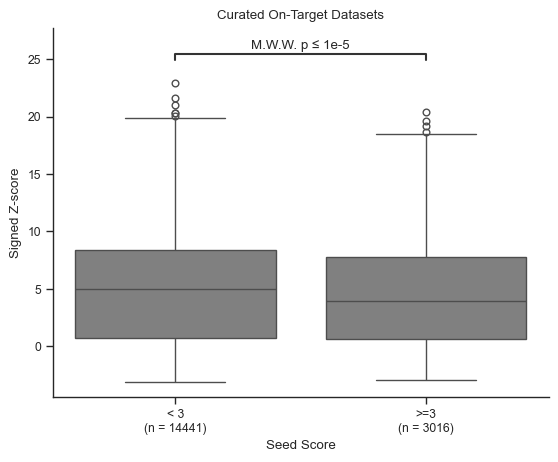

In [9]:
ax = sns.boxplot(data = plot_df, x = 'num_GG_label', y = 'signed_zscore', color = 'gray')

pairs = [('< 3\n(n = 14441)','>=3\n(n = 3016)')]
annotator = Annotator(ax, pairs, data = on_target_tss_proximal, x = 'num_GG_label', y = 'signed_zscore')
annotator.configure(test='Mann-Whitney-gt', text_format='simple', loc='inside')
annotator.apply_and_annotate()

plt.xlabel('Seed Score')
plt.ylabel('Signed Z-score')
plt.title('Curated On-Target Datasets')
sns.despine()

gpp.savefig("../../Figures/Figure 5/on_target_12bp_seed_score_vs_z_score_boxplot.pdf",dpi=300, bbox_inches = 'tight')